# 🥬 FreshRetailNet-50K: Exploratory Data Analysis (EDA)

> **Mục tiêu**: Khám phá dữ liệu để hiểu **bản chất của censored demand** trong bán lẻ thực phẩm tươi sống.

Dựa trên paper: [FreshRetailNet-50K (arXiv:2505.16319)](https://arxiv.org/abs/2505.16319)

In [ ]:
!pip install pyarrow pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
df = pd.read_parquet(data_path + 'train.parquet')

print(f"✅ Shape: {df.shape}")
print(f"✅ Columns: {list(df.columns)}")

Mounted at /content/drive
✅ Shape: (4500000, 19)
✅ Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']


## 1. Thống kê cơ bản

In [ ]:
print(f"Số lượng duy nhất:")
print(f"- city_id: {df['city_id'].nunique()}")
print(f"- store_id: {df['store_id'].nunique()}")
print(f"- product_id: {df['product_id'].nunique()}")
print(f"- third_category_id: {df['third_category_id'].nunique()}")

# Power-law
product_counts = df['product_id'].value_counts()
top_20_pct = int(0.2 * len(product_counts))
top_transactions = product_counts.iloc[:top_20_pct].sum()
total = len(df)
print(f"\nTop 20% SKU chiếm {top_transactions / total:.1%} giao dịch (paper: 51.8%)")

Số lượng duy nhất:
- city_id: 18
- store_id: 898
- product_id: 865
- third_category_id: 233

Top 20% SKU chiếm 78.7% giao dịch (paper: 51.8%)


## 2. Stockout Rate (6h–22h)

Stockout rate (6h–22h): 78.83% (paper: ~20%)


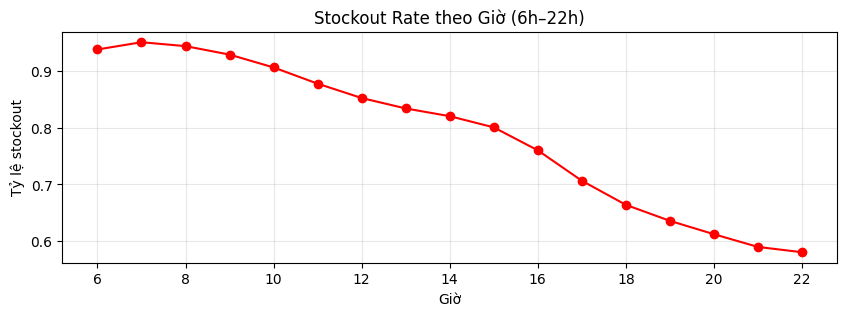

In [ ]:
all_stock_6_22 = np.concatenate([np.array(row)[6:23] for row in df['hours_stock_status'].values])
stockout_rate = (all_stock_6_22 == 0).mean()
print(f"Stockout rate (6h–22h): {stockout_rate:.2%} (paper: ~20%)")

# Stockout rate theo giờ
stockout_by_hour = []
for h in range(6, 23):
    vals = [row[h] for row in df['hours_stock_status'].values]
    rate = (np.array(vals) == 0).mean()
    stockout_by_hour.append(rate)

plt.figure(figsize=(10, 3))
plt.plot(range(6, 23), stockout_by_hour, 'ro-')
plt.title("Stockout Rate theo Giờ (6h–22h)")
plt.xlabel("Giờ")
plt.ylabel("Tỷ lệ stockout")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Intraday Sales Pattern

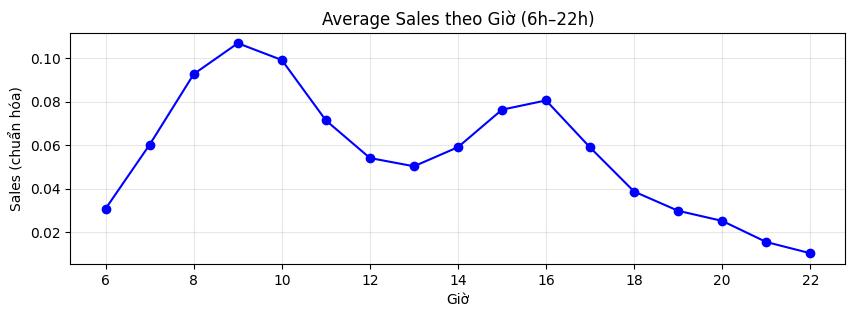

→ Peak tại 9h và 16h → khớp với paper (Figure 2)


In [ ]:
all_sales = np.vstack(df['hours_sale'].values)
avg_sales_6_22 = all_sales[:, 6:23].mean(axis=0)

plt.figure(figsize=(10, 3))
plt.plot(range(6, 23), avg_sales_6_22, 'bo-')
plt.title("Average Sales theo Giờ (6h–22h)")
plt.xlabel("Giờ")
plt.ylabel("Sales (chuẩn hóa)")
plt.grid(True, alpha=0.3)
plt.show()

print("→ Peak tại 9h và 16h → khớp với paper (Figure 2)")

## 4. Tương quan giữa Stockout và Covariates

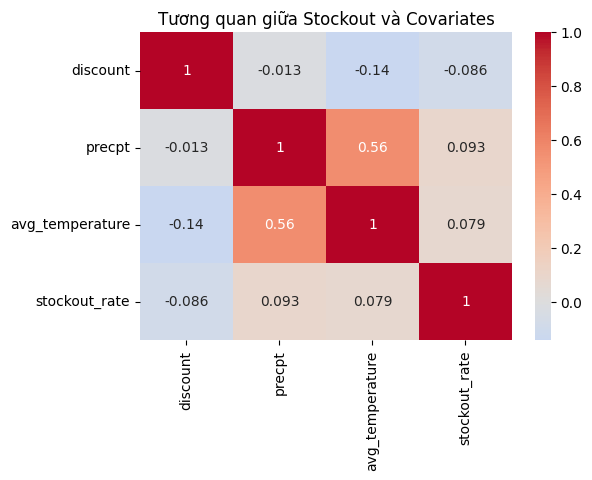

In [ ]:
# Lấy mẫu 1000 dòng để tính tương quan
sample = df.head(1000).copy()
stockout_rates = []
for _, row in sample.iterrows():
    stock = np.array(row['hours_stock_status'])[6:23]
    stockout_rates.append((stock == 0).mean())

sample['stockout_rate'] = stockout_rates

# Tính corr
corr_cols = ['discount', 'precpt', 'avg_temperature', 'stockout_rate']
corr = sample[corr_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Tương quan giữa Stockout và Covariates")
plt.show()

## ✅ Kết luận EDA

- Dữ liệu có **stockout rate cao** → phù hợp để benchmark **latent demand recovery**.
- **Intraday pattern rõ ràng**: peak 9h & 16h → cần mô hình đa chu kỳ.
- **Phân bố SKU theo power-law** → cần xử lý long-tail items.
- **Stockout liên quan đến discount & thời tiết** → không ngẫu nhiên (MNAR).

→ Dữ liệu **phù hợp để xây dựng hệ thống Predictive + Prescriptive AI**.